Flipkart Product Reviews Sentiment Analysis

In [56]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from nltk import PorterStemmer, WordNetLemmatizer
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [58]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [59]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [60]:
# load dataset

# read dataset and display first 5 rows of the dataset
df = pd.read_csv("/content/drive/MyDrive/SCA Assignment Folder/SCA Mini Project 3/Dataset-SA.csv")

df.head(10)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,the cooler is really fantastic and provides go...,positive
6,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,highly recommended,very good product,positive
7,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,nice,very nice,positive
8,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,unsatisfactory,very bad cooler,negative
9,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,4,worth the money,very good,positive


In [61]:
# inspect dataset

# (rows, columns)
print(df.shape)
print("\n")
print("---------------------------------------------------------------------------------------------------")

# dtypes + nulls
print("\n")
print(df.info())

(205052, 6)


---------------------------------------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None


In [62]:
# calculate percentage of missing values in each column
missing_percent = df.isnull().sum() / len(df) * 100
print(missing_percent.sort_values(ascending=False))

Review           12.028168
Summary           0.005364
product_price     0.000000
product_name      0.000000
Rate              0.000000
Sentiment         0.000000
dtype: float64


In [63]:
# cleaning columns name : header
print(df.columns.tolist())
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("FIX APPLIED")
print(df.columns.tolist())

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']
FIX APPLIED
['product_name', 'product_price', 'rate', 'review', 'summary', 'sentiment']


In [64]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert Rate to numeric, errors='coerce' to handle non-numeric values
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Convert product_price to numeric
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')

In [65]:
# Drop rows from the dataframe

# Drop rows where 'review' is empty (NaN)
df = df.dropna(subset=['review'])

# Drop rows where 'summary' is empty (NaN)
df = df.dropna(subset=['summary'])

# Drop rows that contain only whitespace/empty strings
df = df[df['review'].str.strip() != ""]
df = df[df['summary'].str.strip() != ""]

In [66]:
# print out the shape of the dataframe after cleaning
print(len(df))
print(df.shape)

154467
(154467, 6)


In [67]:
print(df["sentiment"].value_counts())

sentiment
positive    122808
negative     23353
neutral       8306
Name: count, dtype: int64


/tmp/ipykernel_3299/1986228804.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Text(0.5, 1.0, 'Distribution of Sentiments')

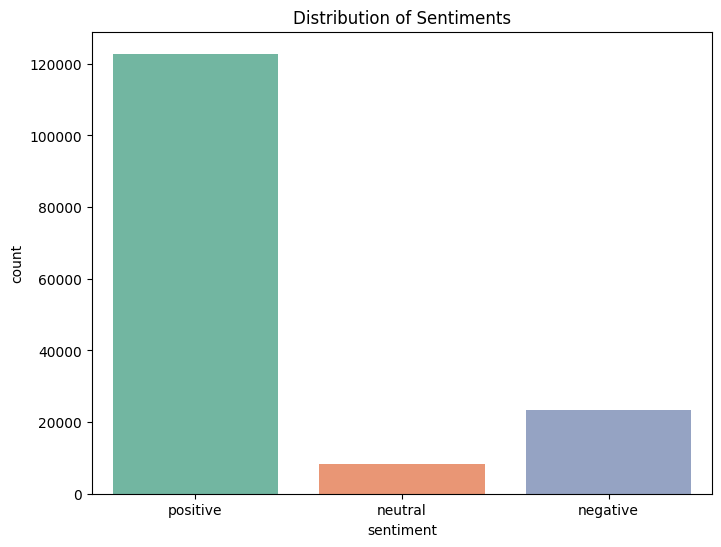

In [68]:
# Visualization: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='Set2', order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Sentiments')

/tmp/ipykernel_3299/2181904537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Text(0.5, 1.0, 'Distribution of Ratings')

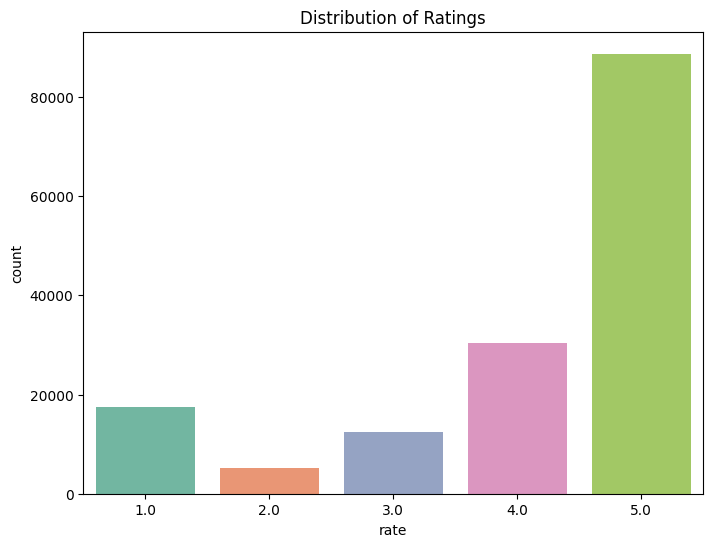

In [69]:
# Visualization: Rate Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='rate', data=df, palette='Set2')
plt.title('Distribution of Ratings')

/tmp/ipykernel_3299/834246955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Text(0.5, 1.0, 'Rate vs Sentiment')

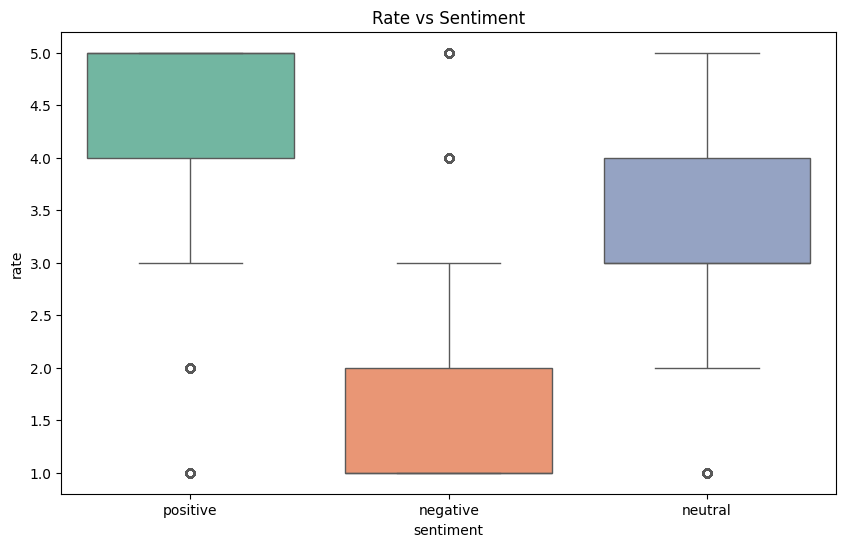

In [70]:
# Visualization: Rate vs Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='rate', data=df, palette='Set2')
plt.title('Rate vs Sentiment')

In [71]:
# Combine review and summary for analysis
df['text'] = df['review'].fillna('') + " " + df['summary'].fillna('')

# lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# function
def preprocess(text):
    # Lowercase
    text = str(text).lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Lemmatize, remove stop words, and keep words longer than 2 chars
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess)

# Group cleaned text by sentiment
pos_words = ' '.join(df[df['sentiment'] == 'positive']['cleaned_text'])
neg_words = ' '.join(df[df['sentiment'] == 'negative']['cleaned_text'])
neu_words = ' '.join(df[df['sentiment'] == 'neutral']['cleaned_text'])


In [72]:
# Get top 10 most common words
pos_split = Counter(pos_words.split()).most_common(10)
neg_split = Counter(neg_words.split()).most_common(10)
neu_split = Counter(neu_words.split()).most_common(10)

print("Top 10 Positive Words:", pos_split)
print("Top 10 Negative Words:", neg_split)
print("Top 10 Neutral Words:", neu_split)

Top 10 Positive Words: [('good', 66463), ('product', 65011), ('nice', 33481), ('quality', 17494), ('awesome', 15721), ('best', 14314), ('money', 11096), ('super', 10535), ('worth', 10390), ('purchase', 10329)]
Top 10 Negative Words: [('product', 10925), ('bad', 5728), ('quality', 5547), ('good', 5535), ('money', 4264), ('waste', 3965), ('worst', 3208), ('poor', 3114), ('dont', 2656), ('buy', 2554)]
Top 10 Neutral Words: [('product', 2661), ('good', 2478), ('quality', 1021), ('nice', 954), ('okay', 791), ('money', 585), ('small', 564), ('average', 508), ('decent', 488), ('job', 488)]


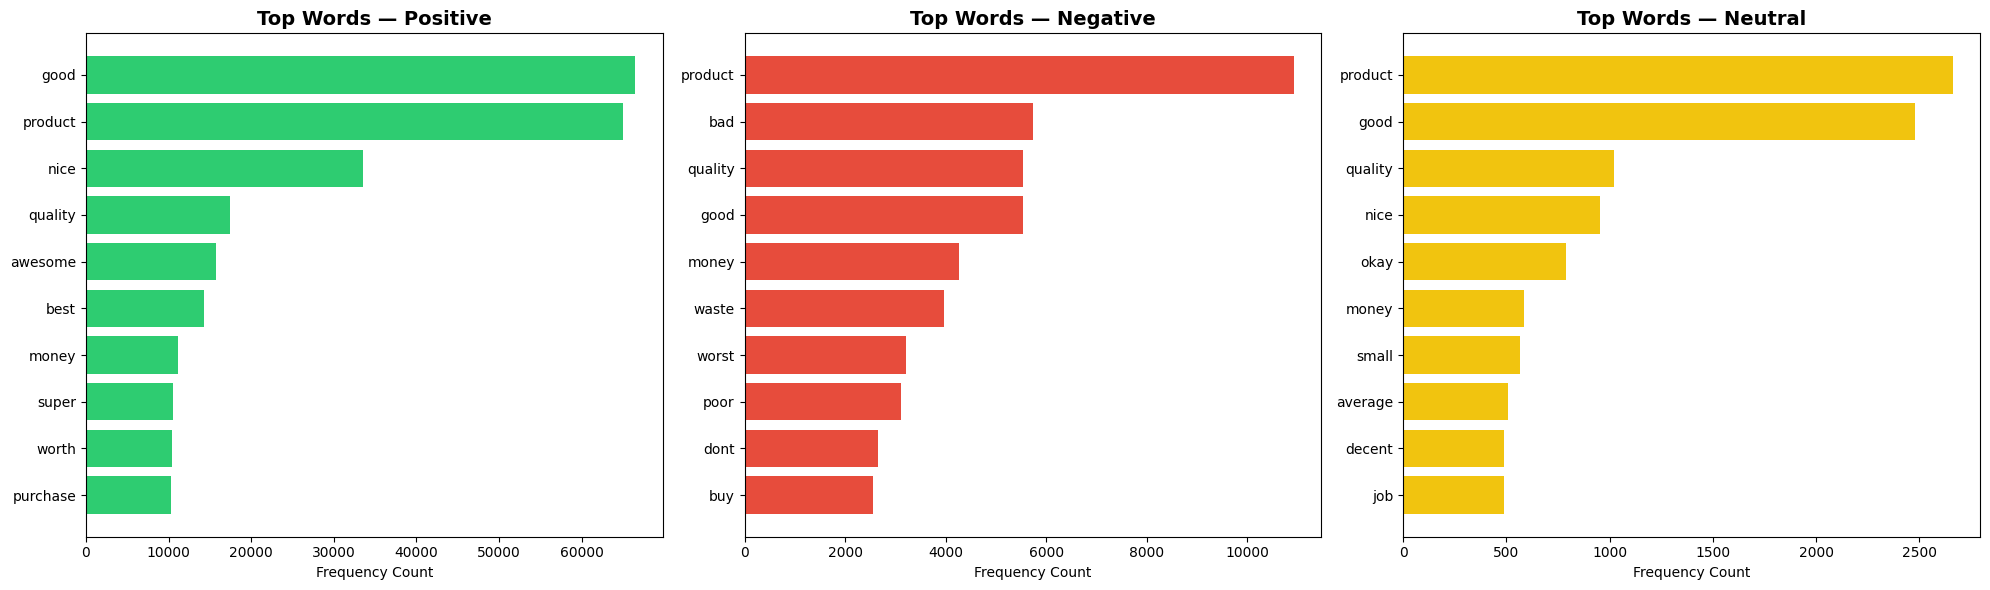

In [73]:
# Visualization: Top 10 words in each sentiment group
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
data = [pos_split, neg_split, neu_split]
colors = ["#2ecc71", "#e74c3c", "#f1c40f"] # Green for pos, Red for neg, Yellow for neu
labels = ["Positive", "Negative", "Neutral"]

for ax, dt, clr, lbl in zip(axes, data, colors, labels):
    if dt:
        words, counts = zip(*dt)
        # Reverse for horizontal bar chart sorting (highest at top)
        ax.barh(list(words)[::-1], list(counts)[::-1], color=clr)
        ax.set_xlabel("Frequency Count")
        ax.set_title(f'Top Words — {lbl}', fontweight='bold', fontsize=14)
    else:
        ax.set_title(f'No Data for {lbl}')

plt.tight_layout()

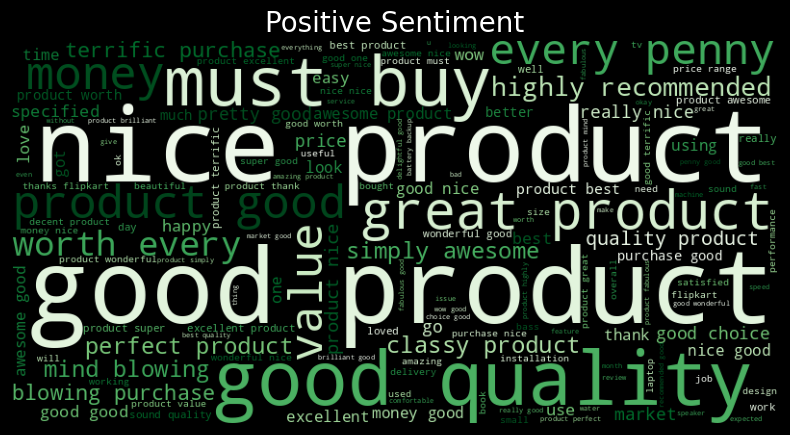

In [74]:
# World Cloud

# Positive Word Cloud (Green)

# Extract Positive Text
pos_text = " ".join(df[df['sentiment'] == 'positive']['text'])

# Generate Cloud
wc_pos = WordCloud(width=800, height=400,
                   background_color='black',
                   colormap='Greens',
                   max_words=150).generate(pos_text)

# Plot
plt.figure(figsize=(10, 5), facecolor='black')
plt.imshow(wc_pos)
plt.axis('off')
plt.title('Positive Sentiment', color='white', fontsize=20)
plt.show()

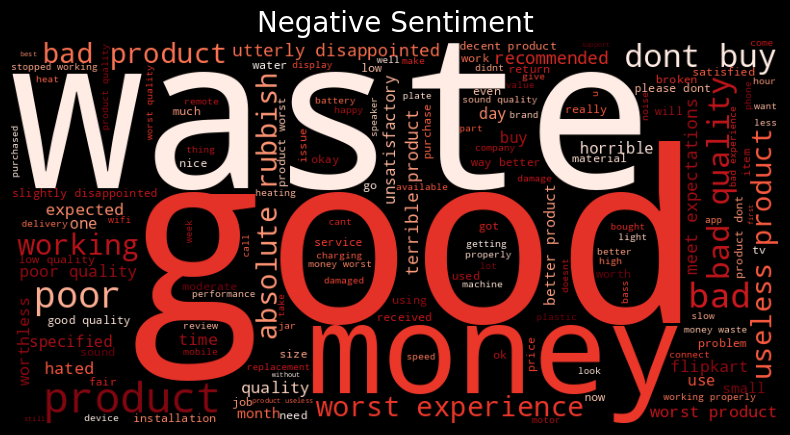

In [75]:
# Negative Word Cloud (Red)

# Extract Negative Text
neg_text = " ".join(df[df['sentiment'] == 'negative']['text'])

# Generate Cloud
wc_neg = WordCloud(width=800, height=400,
                   background_color='black',
                   colormap='Reds',
                   max_words=150).generate(neg_text)

# Plot
plt.figure(figsize=(10, 5), facecolor='black')
plt.imshow(wc_neg)
plt.axis('off')
plt.title('Negative Sentiment', color='white', fontsize=20)
plt.show()

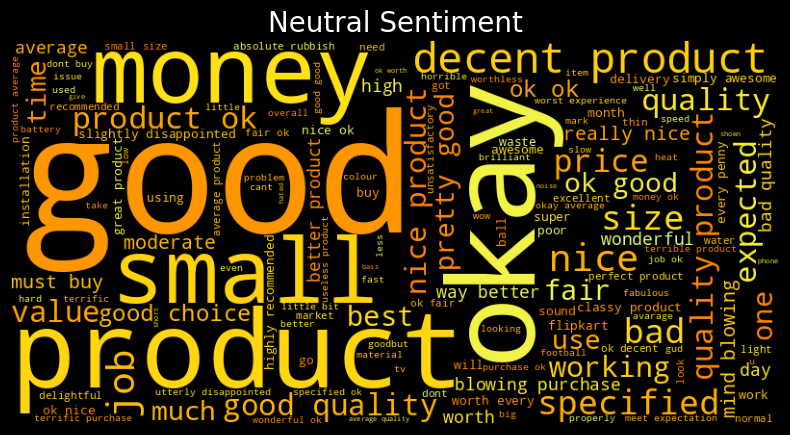

In [76]:
# Neutral Word Cloud (Yellow)

# Extract Neutral Text
neu_text = " ".join(df[df['sentiment'] == 'neutral']['text'])

# Generate Cloud
wc_neu = WordCloud(width=800, height=400,
                   background_color='black',
                   colormap='Wistia',
                   max_words=150).generate(neu_text)

# Plot
plt.figure(figsize=(10, 5), facecolor='black')
plt.imshow(wc_neu)
plt.axis('off')
plt.title('Neutral Sentiment', color='white', fontsize=20)
plt.show()

In [77]:
# Machine Learning Model

df['text'] = df['review'].astype(str) + " " + df['summary'].astype(str)

In [78]:
# 2. Encode Labels (positive=2, neutral=1, negative=0)
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

In [79]:
# 3. Train-Test Split
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (123573,), Test: (30894,)


In [80]:
# 4. Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [81]:
# 5. Model Training (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [82]:
# 6. Predictions
y_pred = model.predict(X_test_tfidf)

# 7. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.9351

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      4671
     neutral       0.68      0.37      0.48      1661
    positive       0.96      0.98      0.97     24562

    accuracy                           0.94     30894
   macro avg       0.84      0.75      0.78     30894
weighted avg       0.93      0.94      0.93     30894



Text(0.5, 1.0, 'Confusion Matrix')

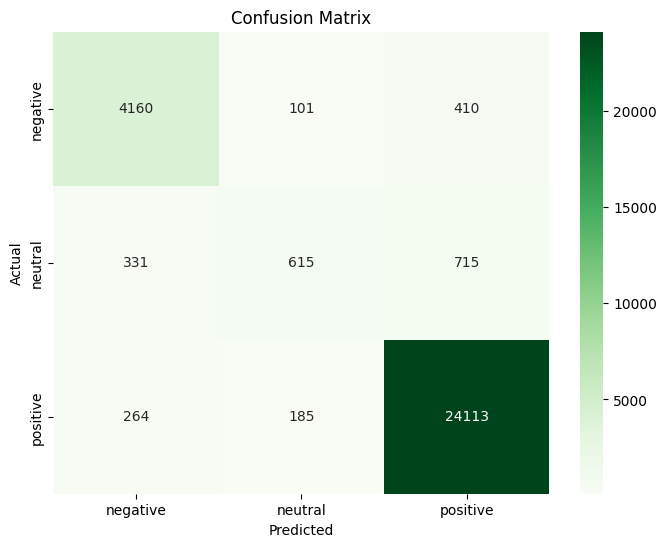

In [83]:
# 8. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

Report:

The Exploratory Data Analysis (EDA) identified different language markers across sentiment groups. Positive feedback was characterized by terms such as "nice" and "quality," while negative feedback centered on "bad" and "waste."



_



The Logistic Regression model, using TF-IDF Vectorization, achieved an overall accuracy of 93.5%. The model demonstrated high precision in identifying positive ($96\%$) and negative ($87\%$) reviews. While the neutral class remains a challenge due to class imbalance. It is slightly weaker with neutral reviews because there were not as many examples to learn from, but it is still highly reliable for identifying happy or unhappy customers.